# Instructions

Dear Alexis,

As discussed earlier, we would like to proceed with the technical part of the interview with you.

Please find below a link to a sample dataset for download:

https://share.mxwbio.com/d/cad4d814258841b0947d/


This data comes from a retina recording where different moving bars were presented to the retina, eliciting responses from the cells. The dataset includes a data matrix containing raw signals and the X/Y coordinates of the recording electrodes, among others.

Please let us know if you have any questions about the file format.

Part 1
Compute the spike-triggered average for two neurons (e.g. ±20 samples) and visualize
the average spatially across all electrodes, i.e., each spike-triggered average for each electrode
should be plotted at the corresponding X/Y position.

Part 2
Identify potential metrics that could be inferred from this dataset and implement a robust way to extract them.

Part 3
Use the extracted metrics to characterize the evoked light responses. Identify how many different conditions were observed presented in the recording and describe how they differ from each other.

Please note the following further information about the H5 file:

1. The frame numbers are embedded in the two highest channels of the "/sig" H5 data matrix.
Therefore, to compute the frame numbers, use an approach like:

low_fn = f['sig'][1026,rng]
high_fn = f['sig'][1027,rng]
frame_nos = (high_fn.astype(np.uint32) << 16) | low_fn.astype(np.uint32)

2. In the H5 dataset '/proc0/spikeTimes' there are precomputed spike times. Together with their channel and frame number, where they have been detected. However, there is a shift of roughly 1880 frames between the two frame numbers. Furthermore, it is recommended to recompute the spike times from the '/sig' data structure.

Thank you very much for your participation in this technical challenge.

Please don't spend more than 4-6 hours on the challenge.

And please let us know if you have any questions about the task.

We look forward to your insights! Once you finish with the 3 tasks above, please send me your solutions back via email. And we can then arrange a time slot to discuss your results together.

Best regards,
Jan

# Assignment

In [155]:
# Imports
from pathlib import Path
import h5py
import numpy as np
from datetime import datetime  # To parse date
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, lfilter  # For bandpass filter

# Set style to ticks and context of plots
sns.set_style("ticks")
sns.set_context("notebook")

# Magics
%matplotlib inline

In [2]:
# Load data
path = Path('/Users/alexis/Downloads/Trace_20161124_15_13_24.raw.h5')
f = h5py.File(path, 'r')

In [3]:
# Inspect data structure
def print_tree(name, obj):
    print(name, type(obj))
f.visititems(print_tree)

bits <class 'h5py._hl.dataset.Dataset'>
mapping <class 'h5py._hl.dataset.Dataset'>
proc0 <class 'h5py._hl.group.Group'>
proc0/spikeTimes <class 'h5py._hl.dataset.Dataset'>
settings <class 'h5py._hl.group.Group'>
settings/gain <class 'h5py._hl.dataset.Dataset'>
sig <class 'h5py._hl.dataset.Dataset'>
time <class 'h5py._hl.dataset.Dataset'>
version <class 'h5py._hl.dataset.Dataset'>


In [4]:
# Unpack small datasets
mapping = f['/mapping'][:]
spike_times = f['proc0/spikeTimes'][:]  # Precomputed spike times
gain = f['settings/gain'][:]
time = f['time'][:]

In [13]:
# Unpack main data matrix
sig = f['/sig']
n_channels, n_frames = sig.shape
print(f'{n_channels} channels\n'
      f'{n_frames} frames')

# Extract channels hosting embedded frames
frame_low_ch = n_channels - 2
frame_high_ch = n_channels - 1

# Extract frame numbers
low_fn = sig[frame_low_ch, :]  # Lower 16 bits halve
high_fn = sig[frame_high_ch, :]  # Lower 16 bits halve
frame_nos = (high_fn.astype(np.uint32) << 16) | low_fn.astype(np.uint32)  # Full 32 bit frame numbers

1028 channels
1755200 frames


In [23]:
# Get REC length and sampling rate
print(time)
s = time[0].decode()
start_str = s.split('start: ')[1].split(';')[0]
stop_str  = s.split('stop: ')[1].strip()
fmt = "%Y-%m-%d %H:%M:%S"
start = datetime.strptime(start_str, fmt)
stop  = datetime.strptime(stop_str, fmt)
duration = (stop - start).total_seconds()
print(f'REC length: {duration:.2f} seconds')

fs = n_frames / duration  # Inferred from data (specs say 20 kHz)
print(f'Sampling rate: {fs / 1000:.2f} kHz')

[b'start: 2016-11-24 15:13:24;\nstop: 2016-11-24 15:14:52\n']
REC length: 88.00 seconds
Sampling rate (inferred from data): 19.95 kHz


Recording from 2016. Probably the stimuli were moving bars at different orientations (8 spaced in 45º), speeds (3) or brightness (2), but this is just a guess based on visual system experiments at the time. We will try to identify the conditions from the data itself.

In [24]:
# Get REC length from precomputed spike times (sanity check)
dur_st = (spike_times['frameno'].max() - spike_times['frameno'].min()) / fs
print(f'REC length (from precomputed spike times): {dur_st:.2f} seconds')

REC length (from precomputed spike times): 87.75 seconds


## Processing


### Find 2 good example neurons (channels)

In [ ]:
# Quick scan of channel activity to identify potential neurons
def plot_channel_std(n_samples=10000):
    """
    Plot standard deviation of each channel as a simple proxy for activity (spiking = high variance).
    :param n_samples: Number of samples to use for quick estimation (default: 10k)
    """

    channel_std = []  # Simple proxy: signal variability (spikes = high variance)
    for ch in range(n_channels - 2):  # Start small, expand if needed
        x = sig[ch, :n_samples]  # Tiny chunk for speed
        channel_std.append(np.std(x))
    channel_std = np.array(channel_std)
    plt.plot(channel_std)
    plt.title("Channel std (activity proxy)")
    plt.xlabel("Channel #")
    plt.ylabel("std")

Top active channels: [583 387]


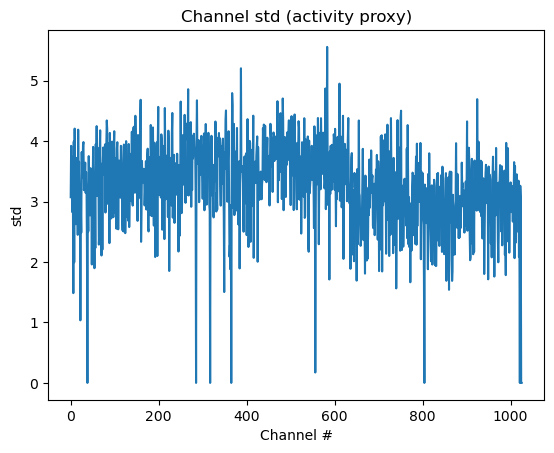

In [367]:
plot_channel_std()
top = 2  # Number of channels to inspect further (2 example neurons)
top_channels = np.argsort(channel_std)[::-1][:top]
print(f'Top active channels: {top_channels}')

### Get spike times for selected neurons (channels)

#### Precomputed

415 channels with no precomputed spikes
Top 2 channels with most precomputed spikes: [941 962]
Spike counts for top channels: [2719. 2715.]


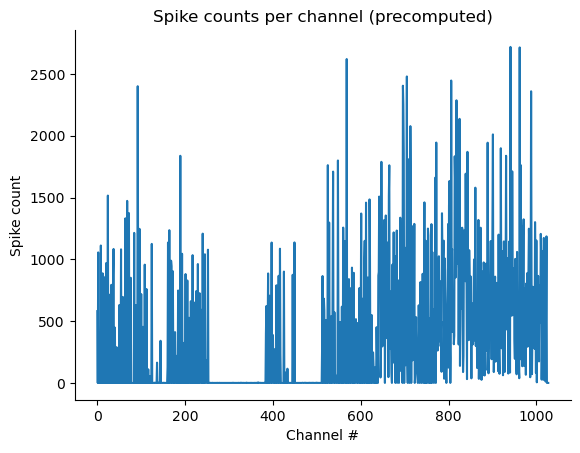

In [369]:
# Get array with the precomputed spikes counts per channel (ground truth?)
spike_counts = np.zeros(sig.shape[0])
for ch in range(sig.shape[0]):
    spike_counts[ch] = np.sum(spike_times['channel'] == ch)
plt.plot(spike_counts)
plt.xlabel("Channel #")
plt.ylabel("Spike count")
plt.title("Spike counts per channel (precomputed)")
sns.despine()

# Find channels with 0 spikes
zero_spike_channels = np.where(spike_counts == 0)[0]
# print(f"Channels with 0 precomputed spikes: {zero_spike_channels}")
print(f'{len(zero_spike_channels)} channels with no precomputed spikes')

# Find 2 channels with the highest spike counts
top_channels = np.argsort(spike_counts)[::-1][:2]
print(f"Top 2 channels with most precomputed spikes: {top_channels}")

# Print spike counts for those 2 channels
print(f"Spike counts for top channels: {spike_counts[top_channels][:2]}")

#### Recomputed from raw signal (recommended)

Standard spike detector (steps):
1. Bandpass filter  (always between recording node and spike detector in Open Ephys, remember?)
2. Robust threshold (std, MAD or percentile?)
3. Detect crossings
4. Align to local minimum
5. Enforce refractory period

Tricky part: balance sensitivity vs false positives

~~[Kilosort 4](https://kilosort.readthedocs.io/en/latest/api.html) uses template deconvolution. Too complex~~

[Open Ephys](https://open-ephys.github.io/gui-docs/User-Manual/Plugins/Spike-Detector.html) uses a simple thresholding method. Implement version of this

In [85]:
def detect_spikes(trace, bandpass=[300, 3000], samplerate=20000, k=4, refractory=20):
    """
    Detect spikes in a voltage trace using a simple thresholding method.
    :param trace: 1D numpy array of voltage values
    :param bandpass: Tuple of (low, high) frequencies for bandpass filter (Hz)
    :param samplerate: Sampling rate of the trace (Hz)
    :param k: Threshold factor for robust thresholding (low/sensitive, high/conservative)
    :param refractory: Minimum number of samples between detected spikes to enforce a refractory period (assuming a fs=20 kHz, 20 samples = 1 ms)
    """

    # Bandpass filter (Butterworth, forward only like Open Ephys example)
    # https://open-ephys.github.io/gui-docs/User-Manual/Plugins/Bandpass-Filter.html#bandpassfilter
    b, a = butter(2, np.array(bandpass) / (samplerate / 2), btype='bandpass')
    trace = lfilter(b, a, trace)

    # thr = np.mean(trace) - 4 * np.std(trace)  # Too restrictive (inflated by spikes)
    # thr = np.percentile(trace, percentile)  # Arbitrary
    sigma = np.median(np.abs(trace)) / 0.6745  # median(|x|) ≈ 0.6745 * σ for Gaussian data
    thr = -k * sigma  # MED (Quian Quiroga, 2004)

    # Find candidate samples below threshold
    candidates = np.where(trace < thr)[0]

    spikes = []
    last = -np.inf  # First spike always accepted

    # Enforce refractory period
    for t in candidates:
        if t - last <= refractory:
            continue

        # Keep only local minima (points lower that their immediate neighbors)
        if 0 < t < len(trace) - 1:
            if trace[t] < trace[t - 1] and trace[t] < trace[t + 1]:
                spikes.append(t)
                last = t  # Update last spike time

    spikes = np.array(spikes)

    return spikes

In [86]:
def plot_channel_activity(channels, n_frames=5000):
    """
    Plot raw signal traces for selected channels to visually inspect for spiking activity.
    Add detected spikes to assess performance of spike detector.
    :param channels: List of channel indices to plot
    :param n_frames: Number of frames to plot for each channel
    """

    fig, axes = plt.subplots(len(channels), 1, figsize=(12, 8), sharex=True, constrained_layout=True)

    for i, ch in enumerate(channels):

        ax = axes[i] if len(channels) > 1 else axes

        # Plot raw trace
        ax.plot(sig[ch, :n_frames])
        sns.despine(ax=ax)

        # Plot spikes
        spikes = detect_spikes(sig[ch, :n_frames])
        spikes = spikes[spikes < n_frames]
        ax.scatter(spikes, sig[ch, spikes], color='r')
        ax.set_title(f"Channel {ch}")

        # Only keep x-axis spine on last plot
        sns.despine(ax=ax, bottom=(i != len(channels) - 1))

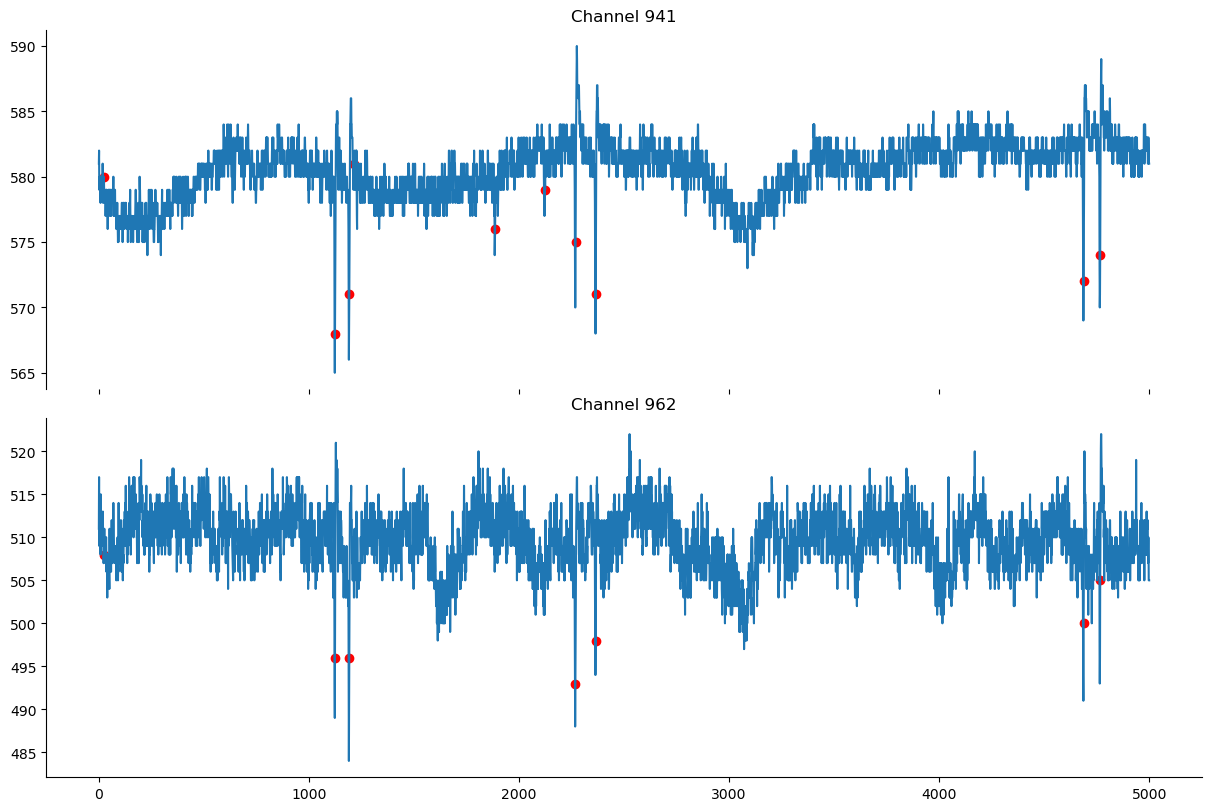

In [370]:
# Plot activity + detected spikes of top 2 channels
plot_channel_activity(top_channels[:2])

Spike detection seems to work fine! Tune further later if time (threshold, refactory period, etc.)

The 2 traces are very similar. It could be due to 2 scenarios:
1. These 2 channels are close and are picking up the same neuron (common in HD-MEA where one neuron can be detected on multiple nearby channels)
2. These 2 channels are picking up different neurons that happen to have very similar activity, possibly driven by the stimulus (maybe normal in cell cultures?)

We can disambiguate this by plotting random channels and see if their spikes correlate. If they do not, then it is likely that the top 2 channels are picking up the same neuron, which would be interesting to see how the STA maps look like across the array for these 2 channels.

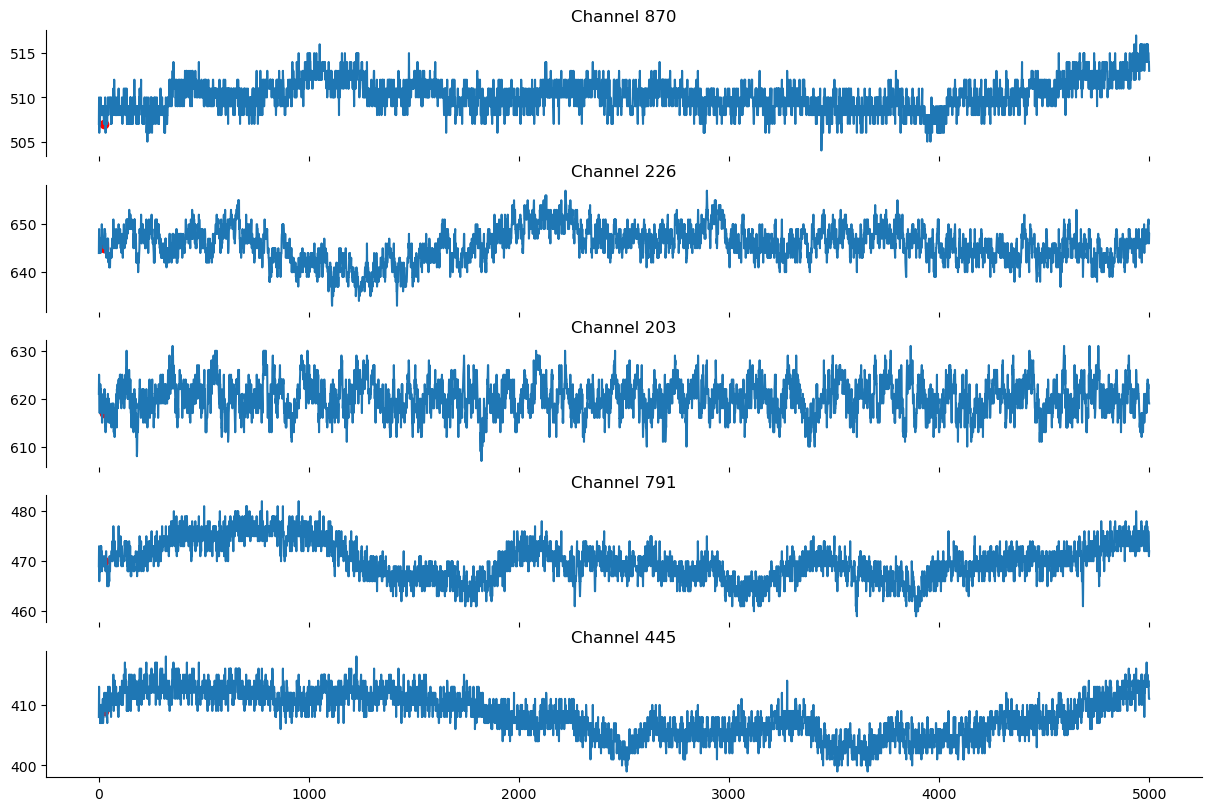

In [364]:
random_channels = np.random.choice(n_channels - 2, size=5, replace=False)
plot_channel_activity(random_channels)

It does not seem that random channels show correlating spiking activity. Therefore, it is likely that the top 2 channels are picking up the same neuron

Confirm this by looking at the spike-triggered average (STA) across the whole array (if they are the same neuron, they should have the same STA map)

## Part 1: Spike-triggered average (STA)

What does the entire HD-MEA 'see' when this neuron fires?

The STA will give us a spatial map of the average signal across the array around the time of each spike, which can help us identify the neuron's location and its relationship to the stimulus. We will compute the STA for the 2 selected channels and plot it spatially using the X/Y coordinates from the mapping.

Formally, for each spike time $t_k$:

$\text{STA}(c, \tau) = \frac{1}{N}\sum_k x_c(t_k + \tau)$,

Where:
* $c$ = electrode/channel
* $\tau$ = time lag around spike (e.g. -20…+20 samples)
* $x_c$ = raw voltage on electrode c
* $t_k$ = spike times

In [90]:
# Remove inactive channels (-1 in electrode?)
electrode = mapping['electrode']
inactive_channels = np.where(mapping['electrode'] == -1)[0]
active_channels = np.where(mapping['electrode'] != -1)[0]
print(f'{len(inactive_channels)} inactive channels')
print(f'{len(active_channels)} active channels')

# Extract variables from mapping (not regular array)
channel = mapping['channel'][active_channels]
# electrode = mapping['electrode'][active_channels]
x_pos = mapping['x'][active_channels]
y_pos = mapping['y'][active_channels]
mapping

495 inactive channels
529 active channels


array([(   0, 10234,  2.1700e+03,  9.625e+02),
       (   1,    -1, -1.0000e+00, -1.000e+00),
       (   2, 10895,  2.1875e+03,  1.015e+03), ...,
       (1021,  6493,  2.1525e+03,  6.650e+02),
       (1022,  6478,  1.8900e+03,  6.650e+02),
       (1023,  6709,  2.0825e+03,  6.825e+02)],
      shape=(1024,), dtype=[('channel', '<i4'), ('electrode', '<i4'), ('x', '<f8'), ('y', '<f8')])

In [103]:
def compute_sta(sig, spikes, window=20):
    """
    Compute spike-triggered average across all channels.
    :param sig: Signal matrix (n_channels, n_frames)
    :param spikes: Spike times (frame indices)
    :param window: Window size before and after spike (samples)
    :return: STA matrix (n_channels, 2 * window)
    """

    n_channels = sig.shape[0]
    sta = np.zeros((n_channels, 2 * window))

    # Only use spikes with sufficient padding
    valid_spikes = spikes[(spikes > window) & (spikes < sig.shape[1] - window)]

    if len(valid_spikes) == 0:
        print("Warning: No valid spikes found!")
        return None

    for t in valid_spikes:
        sta += sig[:, t-window:t+window]

    # To implement: baseline substraction, robust estimator (median?)
    sta /= len(valid_spikes)
    # sta /= np.median(sta)

    return sta

In [101]:
def plot_sta_map(sta, ax=None):
    """
    Compute and plot STA spatial map for a given neuron's spikes.+
    :param sta: STA matrix (n_channels, 2 * window)
    :param ax: Optional matplotlib axes to draw on
    """

    # Find lag with maximum absolute activity
    lag = np.argmax(np.abs(sta).mean(axis=0))

    # Extract values at this lag for active channels only (collapse STA over time)
    c = sta[active_channels, lag]

    if ax is None:
        fig, ax = plt.subplots(constrained_layout=True)

    sc = ax.scatter(x_pos, y_pos,
                    c=c,
                    cmap='RdBu_r',
                    s=100,
                    vmin=-np.max(np.abs(c)),
                    vmax=np.max(np.abs(c)))

    plt.colorbar(sc, ax=ax, label='STA amplitude')
    ax.set_title(f'STA spatial map (lag={lag})')
    ax.set_aspect('equal')
    ax.set_xlabel('x position (μm)')
    ax.set_ylabel('y position (μm)')

Spike counts for channel 0: 1891
Spike counts for channel 2: 1079


Text(0.5, 1.0, 'Channel 2 STA')

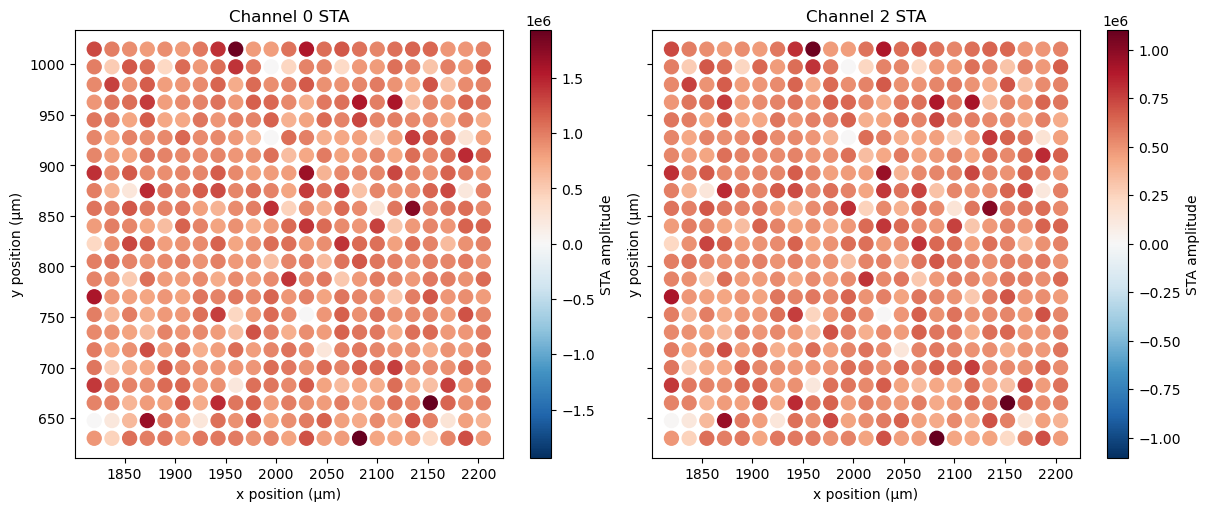

In [363]:
# selected_channels = top_channels
# selected_channels = np.random.choice(n_channels - 2, size=2, replace=False)  # Random channels

# Get spikes
spikes0 = detect_spikes(sig[top_channels[0], :])
# spikes0 = np.random.permutation(spikes0)
spikes1 = detect_spikes(sig[top_channels[1], :])
# spikes1 = np.random.permutation(spikes1)
print(f"Spike counts for channel {top_channels[0]}: {len(spikes0)}")
print(f"Spike counts for channel {top_channels[1]}: {len(spikes1)}")

# Compute STA
sta0 = compute_sta(sig, spikes0)
sta1 = compute_sta(sig, spikes1)

# Plot STA
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True, constrained_layout=True)
plot_sta_map(sta0, ax=axes[0])
plot_sta_map(sta1, ax=axes[1])

# Add channel number to title between parentheses
axes[0].set_title(f'Channel {top_channels[0]} STA')
axes[1].set_title(f'Channel {top_channels[1]} STA')

## Part 2: Metrics extraction

### Spike based

#### Firing rate

In [120]:
def compute_fr(spikes, n_samples, fs=20000):
    """
    Compute firing rate in Hz.
    :param spikes: Array of spike times (frame indices)
    :param n_samples: Number of samples (frames)
    :param fs: Sampling rate in Hz
    :return: Firing rate in Hz
    """
    duration = n_samples / fs  # In seconds (for Hz)
    fr = len(spikes) / duration
    return fr

In [121]:
# Compute firing rate for the 2 example neurons
fr0 = compute_fr(spikes0, sig.shape[1], fs)
fr1 = compute_fr(spikes1, sig.shape[1], fs)
print(f"FR for channel {top_channels[0]}: {fr0:.2f} Hz")
print(f"FR for channel {top_channels[1]}: {fr1:.2f} Hz")

Firing rate for channel 941: 45.27 Hz
Firing rate for channel 962: 34.39 Hz


####  Inter-spike Interval

In [123]:
def compute_isi(spikes, fs):
    """
    Compute inter-spike interval (ISI) distribution.
    :param spikes: Array of spike times (frame indices)
    :param fs: Sampling rate in Hz
    :return: ISI array in seconds
    """
    isi = np.diff(spikes) / fs  # Convert from frames to seconds
    return isi

In [132]:
# Compute ISI for the 2 example neurons
isi0 = compute_isi(spikes0, fs)
isi1 = compute_isi(spikes1, fs)
print(f"Mean ISI for channel {top_channels[0]}: {int(isi0.mean() * 1000)} ms")
print(f"Mean ISI for channel {top_channels[1]}: {int(isi1.mean() * 1000)} ms")

Mean ISI for channel 941: 22 ms
Mean ISI for channel 962: 29 ms


In [137]:
# Check they're inverse of each other
assert np.isclose(1/isi0.mean(), fr0, atol=1), "FR from ISI does not match FR from spike count"
assert np.isclose(1/isi1.mean(), fr1, atol=1), "FR from ISI does not match FR from spike count"

#### Refractory violations

For later: plot autocorrelogram (ACG) to check for refractory period violations

In [141]:
def compute_refractory_violations(spikes, fs, refractory=0.001):
    """
    Compute number of refractory period violations.
    :param spikes: Array of spike times (frame indices)
    :param fs: Sampling rate in Hz
    :param refractory: Refractory period in seconds (default: 1 ms)
    :return: Number of refractory violations
    """
    isi = compute_isi(spikes, fs)
    violations = np.sum(isi < refractory)
    return violations

In [144]:
# Should be 0 by design of the spike detector
violations0 = compute_refractory_violations(spikes0, fs)
violations1 = compute_refractory_violations(spikes1, fs)
print(f"Refractory violations for channel {top_channels[0]}: {violations0}")
print(f"Refractory violations for channel {top_channels[1]}: {violations1}")

Refractory violations for channel 941: 0
Refractory violations for channel 962: 0


### Temporal structure

#### Peri-stimulus time histogram (PSTH)

#### Response latency

#### Burst metrics
(e.g. burst duration, intra-burst frequency, etc.)

### Spatial metrics (MEA specific)

#### Spatial footprint (STA based)
* Number of electrodes with significant STA response (e.g. STA > 3 std) >>> neuron size/spread?
* Peak amplitude location (center of mass)
* Spatial spread (variance). Axonal vs somatic?

#### Propagation dynamics (advanced)
STA lag structure:
* Time delays across electrodes
* Spatial propagation direction

### Stimulus-response metrics
Link to Part 3

#### Tuning curves

#### Selectivity index

#### Direction selectivity index (DSI)

### Population metrics (network level)
Require analyzing full dataset, slow as it is now

#### Correlation / synchrony

#### Population FR

#### Dimensionality (PCA on pupulation FR)

## Part 3: Characterize evoked responses

In [278]:
# top_channels = np.argsort(spike_counts)[::-1][:50]
top_channels = active_channels

(529,)

In [279]:
bin_size = int(0.1 * fs)  # 100 ms bins
n_bins = sig.shape[1] // bin_size

pop = np.zeros((n_bins, len(top_channels)))
for i, ch in enumerate(top_channels):
    spikes = detect_spikes(sig[ch, :])

    # Assign spikes to bins
    for s in spikes:
        b = s // bin_size
        # Ignore spikes outside defined time range
        if b < n_bins:
            pop[b, i] += 1

pop = pop / bin_size * fs  # Convert to FR
pop.shape

(877, 529)

In [355]:
pop_z = (pop - pop.mean(axis=0)) / pop.std(axis=0)  # Zscore
pop_z[np.isnan(pop_z)] = 0  # t-SNE does not accept NaN

/var/folders/8m/2c54y9ts19n1j4y7fy5glf340000gn/T/ipykernel_25705/1788287938.py:1: RuntimeWarning: invalid value encountered in divide
  pop_z = (pop - pop.mean(axis=0)) / pop.std(axis=0)  # Zscore


### Principal Component Analysis (PCA)

In [321]:
from sklearn.decomposition import PCA
pca = PCA(n_components=10)
X_pca = pca.fit_transform(pop_z)

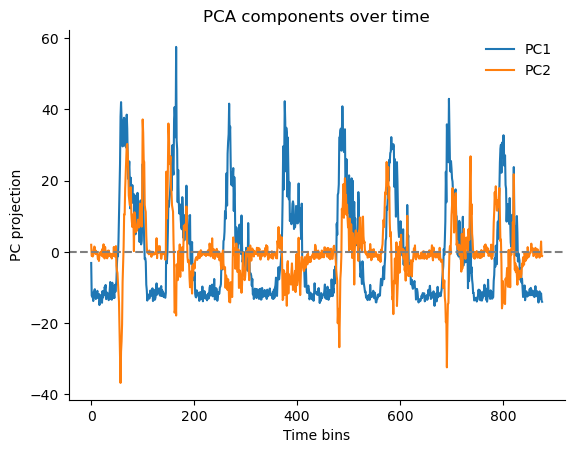

In [336]:
plt.figure()
plt.plot(X_pca[:, 0], label='PC1')
plt.plot(X_pca[:, 1], label='PC2')
plt.axhline(y=0, color='tab:gray', linestyle='--')
# plt.plot(X_pca[:, 2], label='PC3')  # Adds visual noise, explains marginal variance
plt.xlabel('Time bins')
plt.ylabel('PC projection')
plt.title('PCA components over time')
plt.legend(frameon=False)
sns.despine()

PCA captures reliable event structure:
* PC1 has 8 peaks that could correspond to 8 different stimulus orientations. The peaks are evenly spaced, which could reflect the distance in degrees between orientations (360 / 8 = 45º steps). PC1 is always positive, which could mean a global activation / gain axis (stimulus evoked increase in FR). Therefore, PC1 could reflect the strength of the stimulus response.

* PC2 also has 8 peaks, but some are up (positive) others are down (negative). Furthermore, each of these peaks are followed by a 2nd smaller peak. Could that reflect the motion direction? PC2 is orthogonal to PC1, so it likely represents 2 opposing neural subpopulations or 2 opposite tuning directions. So, negative PC2 and postive PC2 could reflect different subpopulations of neurons dominating activity. Alternatively,could the 2nd peak reflect rebound (common in retina: On response, OFF rebound)?

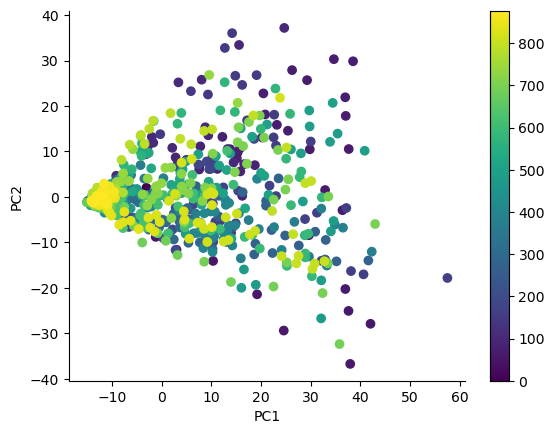

In [362]:
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=np.arange(len(X_pca)))
# Color gradient aligns with cone. PC1 ≈ population FR
# plt.scatter(X_pca[:, 0], X_pca[:, 1], c=X_pca.mean(axis=1))
plt.colorbar()
plt.xlabel('PC1')
plt.ylabel('PC2')
sns.despine()

Variance explained by PC0: 0.41
Variance explained by PC1: 0.12
Variance explained by PC2: 0.07
Variance explained by PC3: 0.04
Variance explained by PC4: 0.03
Variance explained by PC5: 0.03
Variance explained by PC6: 0.02
Variance explained by PC7: 0.01
Variance explained by PC8: 0.01
Variance explained by PC9: 0.01


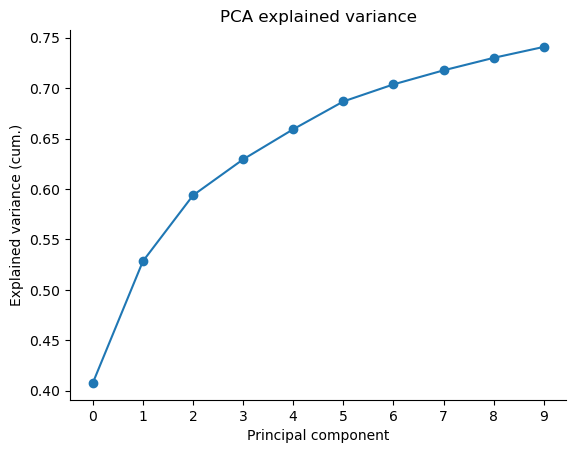

In [361]:
# Plot explained variance
var = pca.explained_variance_ratio_
cumvar = np.cumsum(var)

# plt.plot(var, 'o-', label='Individual')  # Individual variance
plt.plot(cumvar, 'o-', label='Cumulative')  # Cumulative variance
plt.xlabel('Principal component')
plt.ylabel('Explained variance (cum.)')
plt.title('PCA explained variance')
plt.xticks(range(len(var)))
# plt.ylim(None, 1)
# plt.legend(frameon=False)
sns.despine()

for _ in range(len(var)):
    print(f'Variance explained by PC{_}: {var[_]:.2f}')

The first 3 PCs explain 60% of variance.

### t-distributed stochastic neighbor embedding (t-SNE)

Text(0.5, 1.0, 't-SNE embedding')

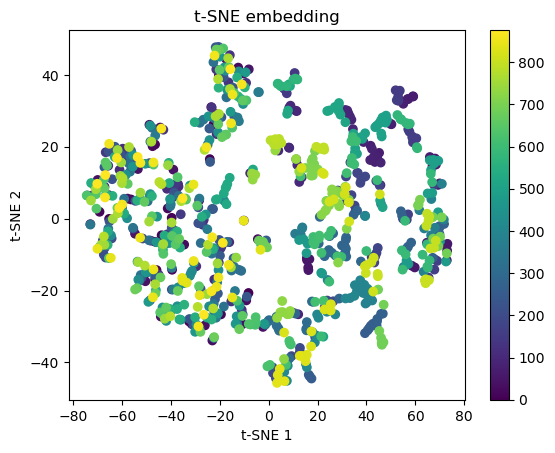

In [360]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=10,  # Try 10–50 depending on data size
    learning_rate='auto',
    # metric='cosine',  # Often better than Euclidean in spike data
    init='pca',
)

# X_pre = PCA(n_components=10).fit_transform(pop_z)
# X_tsne = tsne.fit_transform(X_pre)

X_tsne = tsne.fit_transform(pop_z)

plt.figure()
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=np.arange(len(X_tsne)), cmap='viridis')
plt.colorbar()
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE embedding')

A ring in neural embedding typically indicates a circular latent variable, likely the stimulus orientation (0-360º). Population activity lies on a 1D circular manifold.

It looks like there is certain split between the left and right of the ring (along t-SNE1) that could reflect a second latent variable (like motion direction).